In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import networkExpansionPy.folds as nf
import networkExpansionPy.lib as ne
import glob
import csv
import json
import ast
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from decimal import Decimal
import requests
import random

from sklearn.decomposition import PCA

In [2]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]

    
    return valid_keys, data1, data2

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts', x_range = None):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if not x_range is None:
        plt.xlim([x_range[0], x_range[1]])
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()
    
def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict
        
def rnWith(xgroup, rn2rules):
    rnWithX = []
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                rnWithX.append(reaction)
                break
    return rnWithX
            
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
x2rn = {}
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
for xgroup in x2ns.keys():
    x2rn[xgroup] = rnWith(xgroup, rn2rules)

In [3]:
rn2name = csv2dict('../data/assets/rn2name.csv')
rn2def = csv2dict('../data/assets/rn2def_versions.csv')
rn2eqn = csv2dict('../data/assets/rn2eqn.csv')

cpd2rn = csv2dict('../data/assets/cpd2rn.csv')
cpd2reac = csv2dict('../data/assets/cpd2reac.csv')
cpd2prod = csv2dict('../data/assets/cpd2prod.csv')
cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')

rn2eqn_SI = csv2dict('../data/assets/rn2eqn_SI.csv')
rn2reversible = csv2dict('../data/assets/rn2reversible.csv')

x2name = csv2dict('../data/assets/xgroup2/xgroup2name.csv')

In [4]:
zpd2name = {}

with open('../data/assets/zcpd2name.txt', 'r') as file:
    lines = file.readlines()
    count = 1
    z = 0
    name = 0
    for line in lines:
        if count%2 == 1:  # odd
            z = line.strip()
        else:
            name = line.strip()
        zpd2name[z] = name
        count += 1   

In [5]:
# choose fastest run
batm = pd.read_pickle('../2023-09-21_11-42-33_random_fold_ordering_42287-fixed-rn-seeds.pkl')
# file name is 'random' but it's actualy optimal

In [6]:
folditer2rns = {}
for rn, i in batm.rns_folditer.items():
    if i not in folditer2rns.keys():
        folditer2rns[i] = []
    folditer2rns[i].append(rn)
    
folditer2folds = {}
for rn, i in batm.folds_folditer.items():
    if i not in folditer2folds.keys():
        folditer2folds[i] = []
    folditer2folds[i].append(rn)

In [7]:
folditer2cpd = {}
for c, order in batm.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]

172


# H2O2 timing

In [10]:
batm.cpds_folditer['C00027']

170

In [13]:
for rn in folditer2rns[170]:
    if 'C00027' in rn2eqn_SI[rn]:  # if H2O2 exists in rn equation
        print(rn, rn2eqn_SI[rn], rn2reversible[rn])

R00602_v1 C00132 + C00027 + Z00025 + C00132 + C00027 + Z00025 + C00132 + C00027 + Z00025 => 2C00001 + C00067 + Z00025 + 2C00001 + C00067 + Z00025 + 2C00001 + C00067 + Z00025 False
R09741_v1 C19861 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
R00090_v1 C00027 + C00004 + C00080 + Z00015 => 2C00001 + C00003 + Z00015 False
R04248 C03557 + C00027 => C00189 + C00009 False
R12455 2C00001 + C00032 + C00011 => C22173 + C00027 True
R09740_v1 C05102 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
R00274_v1 2C00051 + C00027 + Z00044 => 2C00001 + C00127 + Z00044 False
R09507_v1 C01335 + C00001 + Z00025 + Z00010 => C01371 + C00027 + Z00025 + Z00010 True
R11522 2C00011 + 4C00001 + C00032 => 2C00027 + C21284 True
R03532_v1 2C00001 + C00028 + Z00025 + 2C00001 + C00028 + Z00025 => C00030 + C00027 + Z00025 + C00030 + C00027 + Z00025 False
R12454 2C00001 + C22173 + C00011 => C21284 + C00027 True
R00113 C00027 + C00005 + C00080 => 2C00001 + C00006 False
R01703 2C00027 + C00249 => 3C00001 + C01948 

In [38]:
# H2O2-producing reactions
for rn in ['R09741_v1', 'R12455', 'R09740_v1', 'R09507_v1', 'R11522', 'R03532_v1', 'R12454']:
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])

R09741_v1 C19861 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
R12455 2C00001 + C00032 + C00011 => C22173 + C00027 True
R09740_v1 C05102 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
R09507_v1 C01335 + C00001 + Z00025 + Z00010 => C01371 + C00027 + Z00025 + Z00010 True
R11522 2C00011 + 4C00001 + C00032 => 2C00027 + C21284 True
R03532_v1 2C00001 + C00028 + Z00025 + 2C00001 + C00028 + Z00025 => C00030 + C00027 + Z00025 + C00030 + C00027 + Z00025 False
R12454 2C00001 + C22173 + C00011 => C21284 + C00027 True


In [14]:
# for the H2O2-producing reactions, by what fold are they gated?
for rn in ['R09741_v1', 'R12455', 'R09740_v1', 'R09507_v1', 'R11522', 'R03532_v1', 'R12454']:
    print(rn2rules[rn])

{frozenset({'149'})}
{frozenset({'304'})}
{frozenset({'149'})}
{frozenset({'108'})}
{frozenset({'304'})}
{frozenset({'2485'}), frozenset({'136'}), frozenset({'149'})}
{frozenset({'304'})}


In [16]:
# H2O2 production rns are NOT gated by fold injected at this folditer
folditer2folds[170]


['330']

In [40]:
# check Z cofactors

for cpd in ['Z00025']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd])
for cpd in ['C00032']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])

170 Z00025 Heme
170 C00032 Heme


## it must instead be gated by Heme

In [21]:
# so which reactions were allowed by X330?

for rn in folditer2rns[170]:
    print(rn, rn2rules.get(rn, 'none'))

R00602_v1 {frozenset({'2485'}), frozenset({'136'}), frozenset({'4028', '4048'})}
R00609_v1 {frozenset({'375', '244', '1', '101', '304'})}
R04972 {frozenset({'2002'})}
R01998 none
RZ_67 none
R12002_v1 {frozenset({'2002'})}
R03950 {frozenset({'7550', '2007', '1137'}), frozenset({'7550', '2003', '1137'}), frozenset({'2007'}), frozenset({'7550', '1137'}), frozenset({'1137', '4049', '4029', '2003', '7550'})}
R03165 {frozenset({'7550', '2007', '1137'}), frozenset({'2007'})}
R00314 none
R04126 none
R09741_v1 {frozenset({'149'})}
R01915_v1 {frozenset({'2003'})}
R01213_v1 {frozenset({'330', '2002', '103'})}
R11629 {frozenset({'2004'})}
RZ_75 none
CoP_syn none
R10015 none
R04043 none
RZ_343 none
RZ_97 none
C18234_syn none
R06895_v2 {frozenset({'2002', '101'})}
RZ_78 none
RZ_39 none
R00090_v1 {frozenset({'244', '2003'})}
RZ_268 none
C01070_syn none
R00313 none
R00312 none
R04311_v1 {frozenset({'217', '304'})}
R05807_v1 {frozenset({'2007'})}
R07411_v1 {frozenset({'141'})}
R04248 none
R03437 {froze

In [24]:
# reactions allowed by X330 at folditer = 170

for rn in ['R01213_v1', 'R00084_v1', 'R07399']:
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])

R01213_v1 C00024 + C00141 + C00001 + Z00026 + Z00030 => C02504 + C00010 + Z00026 + Z00030 True
R00084_v1 4C00931 + C00001 + Z00056 => 4C00014 + C01024 + Z00056 False
R07399 C02612 + C00010 => C00024 + C00022 + C00001 True


In [28]:
for cpd in ['C00024', 'C00141', 'C02504']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])
print('----------')
for cpd in ['C00931', 'C01024']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])
print('----------')
for cpd in ['C02612', 'C00024', 'C00022']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])

103 C00024 Acetyl-CoA
22 C00141 3-Methyl-2-oxobutanoic acid
103 C02504 alpha-Isopropylmalate
----------
103 C00931 Porphobilinogen
170 C01024 Hydroxymethylbilane
----------
4 C02612 (R)-2-Methylmalate
103 C00024 Acetyl-CoA
0 C00022 Pyruvate


In [35]:
# 170 C01024 Hydroxymethylbilane is the heme precursor produced via X330

cpd = 'C01024'
print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])  # cpd
print(batm.cpds_folditer[cpd], cpd, cpd2rn[cpd])  # rn
print('-----------------------------------------')
for next_rn in cpd2rn[cpd]:
    print(batm.rns_folditer[next_rn], next_rn, rn2eqn_SI[next_rn], rn2reversible[next_rn])

170 C01024 Hydroxymethylbilane
170 C01024 ['R00084_v1', 'R03165', 'R03166']
-----------------------------------------
170 R00084_v1 4C00931 + C00001 + Z00056 => 4C00014 + C01024 + Z00056 False
170 R03165 C01024 => C01051 + C00001 False
170 R03166 C01024 => C05766 + C00001 False


In [36]:
for cpd in ['C01051', 'C05766']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])

170 C01051 Uroporphyrinogen III
170 C05766 Uroporphyrinogen I


In [37]:
cpd = 'C01051'
print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])  # cpd
print(batm.cpds_folditer[cpd], cpd, cpd2rn[cpd])  # rn
print('-----------------------------------------')
for next_rn in cpd2rn[cpd]:
    print(batm.rns_folditer[next_rn], next_rn, rn2eqn_SI[next_rn], rn2reversible[next_rn])

170 C01051 Uroporphyrinogen III
170 C01051 ['R03165', 'R03194', 'R03195', 'R03197', 'R07237']
-----------------------------------------
170 R03165 C01024 => C01051 + C00001 False
170 R03194 2C00019 + C01051 => 2C00021 + C02463 False
170 R03195 C01051 + C00028 => 6C00080 + C02469 + C00030 False
170 R03197 C01051 => 4C00011 + C03263 False
170 R07237 C00019 + C01051 => C00021 + C15527 False


In [ ]:
# Check KEGG map for the whole heme biosynth pathway:
#    https://www.genome.jp/module/M00121+C01024

# 103 C00931 Porphobilinogen
# 170 C01024 Hydroxymethylbilane (gated by X330)
# 170 C01079 Protoporphyrinogen IX
# 170 C02191 Protoporphyrin
# 170 C00032 Heme

## ultimately,

In [209]:
# all these reactions must be changed to NOT produce H2O2

# H2O2-producing reactions
for rn in ['R09741_v1', 'R12455', 'R09740_v1', 'R09507_v1', 'R11522', 'R03532_v1', 'R12454']:
    print(batm.rns_folditer[rn], rn, rn2eqn_SI[rn], rn2reversible[rn])

170 R09741_v1 C19861 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
170 R12455 2C00001 + C00032 + C00011 => C22173 + C00027 True
170 R09740_v1 C05102 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
170 R09507_v1 C01335 + C00001 + Z00025 + Z00010 => C01371 + C00027 + Z00025 + Z00010 True
170 R11522 2C00011 + 4C00001 + C00032 => 2C00027 + C21284 True
170 R03532_v1 2C00001 + C00028 + Z00025 + 2C00001 + C00028 + Z00025 => C00030 + C00027 + Z00025 + C00030 + C00027 + Z00025 False
170 R12454 2C00001 + C22173 + C00011 => C21284 + C00027 True


In [206]:
for cpd in ['C19861', 'C00162', 'C00011', 'C22173', 'C05102', 'C01335', 'C01371', 'C21284', 'C00028', 'C00030']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])

170 C19861 3-Hydroxy fatty acid
104 C00162 Fatty acid
0 C00011 CO2
170 C22173 Harderoheme III
170 C05102 alpha-Hydroxy fatty acid
0 C01335 ROH
170 C01371 Alkane
170 C21284 Fe-coproporphyrin III
0 C00028 Acceptor
0 C00030 Reduced acceptor


In [62]:
x2rn['148']

['R00294',
 'R03945',
 'R02468',
 'R02470',
 'R03114',
 'R03877',
 'R06282',
 'R00294_v1',
 'R06282_v1',
 'R03945_v1']

# try H2O2 ablation

In [69]:
noHP = pd.read_pickle('../2024-04-22_20-12-11_H2O2_ablation.pkl.gz')

In [72]:
folditer2rnsHP = {}
for rn, i in noHP.rns_folditer.items():
    if i not in folditer2rnsHP.keys():
        folditer2rnsHP[i] = []
    folditer2rnsHP[i].append(rn)

folditer2foldsHP = {}
for rn, i in noHP.folds_folditer.items():
    if i not in folditer2foldsHP.keys():
        folditer2foldsHP[i] = []
    folditer2foldsHP[i].append(rn)

In [71]:
folditer2cpdHP = {}
for c, order in noHP.cpds_folditer.items():
    if order not in folditer2cpdHP.keys():
        folditer2cpdHP[order] = [c]
    else:
        folditer2cpdHP[order].append(c)
print(len(folditer2cpdHP))
    
folditer2cpdNumHP = {}
for fold in folditer2cpdHP.keys():
    folditer2cpdNumHP[fold] = len(folditer2cpdHP[fold])

folditer2cpdNumFullHP = {}
for i in range(0, max(folditer2cpdHP.keys())):
    if i not in folditer2cpdNumHP.keys():
        folditer2cpdNumFullHP[i] = 0
    else:
        folditer2cpdNumFullHP[i] = folditer2cpdNumHP[i]

print(len(folditer2cpdNumFullHP))

166
350


In [97]:
folditer2foldsHP

{0: ['fold_independent'],
 1: ['spontaneous'],
 2: ['2002'],
 3: ['1'],
 4: ['2487'],
 5: ['2006'],
 6: ['2003'],
 7: ['246'],
 8: ['7525'],
 9: ['62'],
 10: ['7518'],
 11: ['4126'],
 12: ['218'],
 13: ['2007'],
 14: ['304'],
 15: ['12'],
 16: ['11'],
 17: ['10'],
 18: ['109'],
 19: ['210'],
 20: ['7515'],
 21: ['279'],
 22: ['7577'],
 23: ['3016'],
 24: ['281'],
 25: ['7542'],
 26: ['7528'],
 27: ['331'],
 28: ['301'],
 29: ['7572'],
 30: ['2011'],
 31: ['282'],
 32: ['206'],
 33: ['325'],
 34: ['7527'],
 35: ['805'],
 36: ['3691'],
 37: ['7579'],
 38: ['7529'],
 39: ['180'],
 40: ['7512'],
 41: ['7560'],
 42: ['297'],
 43: ['286'],
 44: ['4002'],
 45: ['7554'],
 46: ['315'],
 47: ['2004'],
 48: ['205'],
 49: ['7580'],
 50: ['70'],
 51: ['7574'],
 52: ['208'],
 53: ['7567'],
 54: ['307'],
 55: ['212'],
 56: ['7516'],
 57: ['7561'],
 58: ['387'],
 59: ['5'],
 60: ['247'],
 61: ['7571'],
 62: ['7517'],
 63: ['5104'],
 64: ['7510'],
 65: ['2'],
 66: ['2498'],
 67: ['4081'],
 68: ['611'],

In [98]:
multipleHP = []
for i, folds in folditer2foldsHP.items():
    if len(folds) > 1:
        multipleHP.append(i)

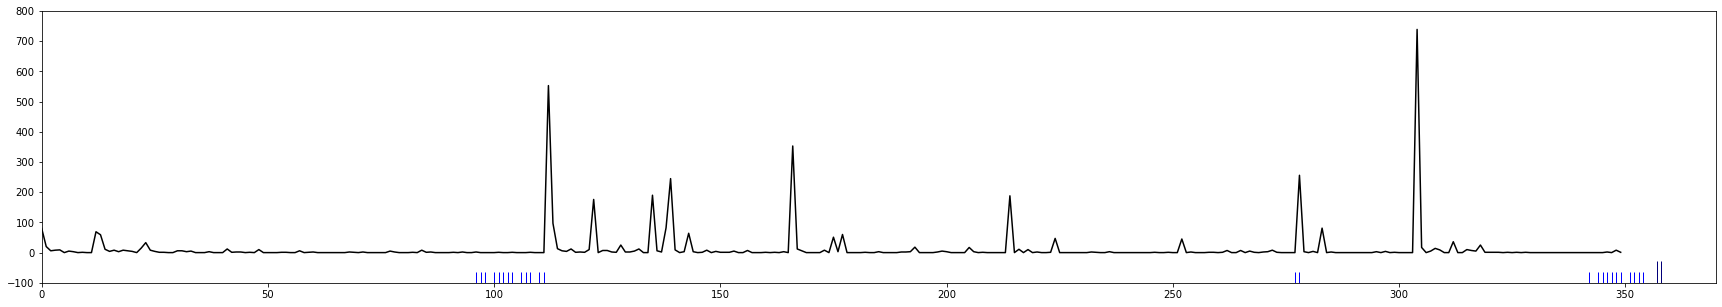

In [100]:
# with P

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullHP.values(), color='k')

# sns.rugplot(batm.folds_folditer.values(), height=0.04)
sns.rugplot(multipleHP, height=0.04, color='blue')  # double fold injection
sns.rugplot([357, 358], height=0.08, color='#020079')  # triple fold injection

plt.xlim([0, 370])
plt.ylim([-100, 800])
# plt.savefig('3B_cpds_withP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [78]:
len(noHP.scope.cpds)

4176

In [126]:
x2foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')

In [127]:
for x in ['278', '604', '7586', '4044', '4017', '2010', '590', '7601', '7602', '3374', '144', '3339', '702']:
    print(batm.folds_folditer[x], x2fo_noHP[x], x2foAveNONE[x])

315 108 210.077
316 108 210.561
292 104 197.081
322 104 209.471
336 105 215.892
350 103 223.947
350 103 223.947
362 102 227.544
362 102 227.544
370 107 230.093
370 107 230.093
367 110 234.845
367 110 234.845


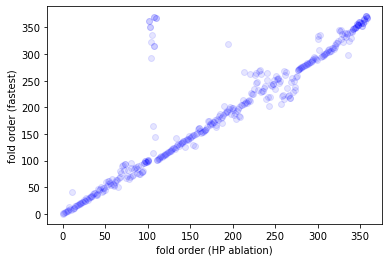

In [203]:
scatter(noHP.folds_folditer, batm.folds_folditer, 'fold order (HP ablation)', 'fold order (fastest)')

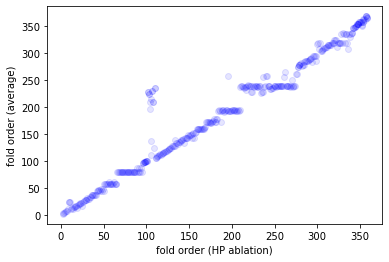

In [136]:
scatter(noHP.folds_folditer, x2foAveNONE, 'fold order (HP ablation)', 'fold order (average)')

In [137]:
# try using bokeh

from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool

# Create a new plot
output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="fold order (HP ablation) vs. fold order (average)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(noHP.folds_folditer, x2foAveNONE)
source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'fold order (HP ablation)'
p.yaxis.axis_label = 'fold order (average)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

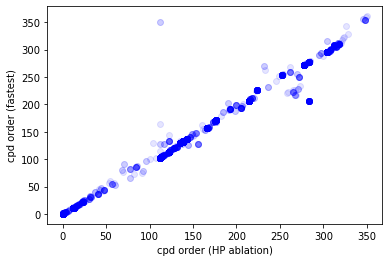

In [202]:
scatter(noHP.cpds_folditer, batm.cpds_folditer, 'cpd order (HP ablation)', 'cpd order (fastest)')

In [82]:
zcpd2name = {}
for c, name in zpd2name.items():
    zcpd2name[c] = name
for c, name in cpd2name.items():
    zcpd2name[c] = name  

In [138]:
# try using bokeh

from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool

# Create a new plot
output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="cpd order (HP ablation) vs. cpd order (fastest) NONE")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(noHP.cpds_folditer, batm.cpds_folditer)
source = {'x': data1, 'y': data2, 'label': [zcpd2name.get(key, '?') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'cpd order (HP ablation)'
p.yaxis.axis_label = 'cpd order (fastest) NONE'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

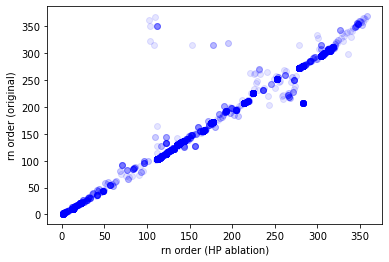

In [123]:
scatter(noHP.rns_folditer, batm.rns_folditer, 'rn order (HP ablation)', 'rn order (fastest) NONE')

## PCA

In [88]:
noHP.folds_folditer

{'fold_independent': 0,
 'spontaneous': 1,
 '2002': 2,
 '1': 3,
 '2487': 4,
 '2006': 5,
 '2003': 6,
 '246': 7,
 '7525': 8,
 '62': 9,
 '7518': 10,
 '4126': 11,
 '218': 12,
 '2007': 13,
 '304': 14,
 '12': 15,
 '11': 16,
 '10': 17,
 '109': 18,
 '210': 19,
 '7515': 20,
 '279': 21,
 '7577': 22,
 '3016': 23,
 '281': 24,
 '7542': 25,
 '7528': 26,
 '331': 27,
 '301': 28,
 '7572': 29,
 '2011': 30,
 '282': 31,
 '206': 32,
 '325': 33,
 '7527': 34,
 '805': 35,
 '3691': 36,
 '7579': 37,
 '7529': 38,
 '180': 39,
 '7512': 40,
 '7560': 41,
 '297': 42,
 '286': 43,
 '4002': 44,
 '7554': 45,
 '315': 46,
 '2004': 47,
 '205': 48,
 '7580': 49,
 '70': 50,
 '7574': 51,
 '208': 52,
 '7567': 53,
 '307': 54,
 '212': 55,
 '7516': 56,
 '7561': 57,
 '387': 58,
 '5': 59,
 '247': 60,
 '7571': 61,
 '7517': 62,
 '5104': 63,
 '7510': 64,
 '2': 65,
 '2498': 66,
 '4081': 67,
 '611': 68,
 '7552': 69,
 '64': 70,
 '2005': 71,
 '103': 72,
 '328': 73,
 '708': 74,
 '3847': 75,
 '7520': 76,
 '185': 77,
 '810': 78,
 '3651': 79,
 

In [89]:
data_path = '../fold_iters_pre_expansion.csv'
with open(data_path, 'r') as file:
    lines = file.readlines()

xgroups = []
for line in lines:
    if line[0] == ',':
        xgroups = line.split(',')[1:-3]
        break

In [95]:
len(noHP.folds_folditer), len(batm.folds_folditer)

(389, 399)

In [104]:
# some folds are never added!
set(batm.folds_folditer.keys()) - set(noHP.folds_folditer.keys())

{'228', '3752', '3960', '4028', '4046', '4048', '4110', '558', '6', '881'}

In [ ]:
# let's just say they're all injected after the last iter

In [108]:
# re-order to fit fold_iters_pre-expansion.csv
x2fo_noHP = {}

for x in xgroups:
    if x not in {'228', '3752', '3960', '4028', '4046', '4048', '4110', '558', '6', '881'}:
        x2fo_noHP[x] = noHP.folds_folditer[x]
    else:
        x2fo_noHP[x] = 359

In [109]:
x2fo_noHP

{'fold_independent': 0,
 'spontaneous': 1,
 '2002': 2,
 '1': 3,
 '2487': 4,
 '2006': 5,
 '2003': 6,
 '246': 7,
 '7525': 8,
 '218': 12,
 '2007': 13,
 '304': 14,
 '12': 15,
 '11': 16,
 '109': 18,
 '10': 17,
 '210': 19,
 '7515': 20,
 '279': 21,
 '7577': 22,
 '3016': 23,
 '281': 24,
 '7528': 26,
 '331': 27,
 '7542': 25,
 '301': 28,
 '7572': 29,
 '2011': 30,
 '325': 33,
 '206': 32,
 '282': 31,
 '7527': 34,
 '805': 35,
 '7529': 38,
 '7512': 40,
 '3691': 36,
 '7518': 10,
 '7579': 37,
 '62': 9,
 '4126': 11,
 '7560': 41,
 '180': 39,
 '7554': 45,
 '315': 46,
 '70': 50,
 '297': 42,
 '7580': 49,
 '4002': 44,
 '286': 43,
 '2004': 47,
 '205': 48,
 '7561': 57,
 '7517': 62,
 '7574': 51,
 '387': 58,
 '7571': 61,
 '5': 59,
 '247': 60,
 '7567': 53,
 '212': 55,
 '7510': 64,
 '5104': 63,
 '307': 54,
 '2': 65,
 '208': 52,
 '7516': 56,
 '7573': 95,
 '328': 73,
 '611': 68,
 '4021': 82,
 '298': 83,
 '7520': 76,
 '164': 90,
 '2498': 66,
 '4081': 67,
 '3651': 79,
 '810': 78,
 '2485': 92,
 '149': 91,
 '632': 93,


In [111]:
# dict2csv(x2fo_noHP, 'x2fo_noHP.csv') 

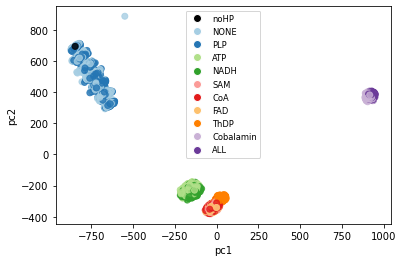

In [117]:
# add "withP" run and "noHP" run

data_path = '../fold_iters_pre_expansion_withP_noHP.csv'
with open(data_path, 'r') as file:
    lines = file.readlines()

data = []  # 10,002 * 397
labels = []  # 10,002
for line in lines:
    if line[0] == ',':
        continue
    fo = line.split(',')[3:-3]
    pre = line.split(',')[-1].strip()  # pre-expansion labels
    data.append(fo)
    labels.append(pre)
np.array(data)
df = pd.DataFrame(data, index=labels)

label_colors = {'noHP': 'black', 'NONE': '#A6CEE3', 'C00002': '#B1E08A', 'C00004': '#31A12C', 'C00010': '#E21C1C', 'C00016': '#FDC16E', 'C00019': '#FB9B98', 'Z00009': '#CAB2D6', 'Z00035': '#2576B4', 'Z00047': '#FF8000', 'ALL': '#6B3A99'}
label_colors2 = {'noHP': 'noHP','NONE': 'NONE', 'Z00035': 'PLP', 'C00002': 'ATP', 'C00004': 'NADH', 'C00019': 'SAM', 'C00010': 'CoA', 'C00016': 'FAD', 'Z00047': 'ThDP', 'Z00009': 'Cobalamin', 'ALL': 'ALL'}
# Map index values to their corresponding colors
colors_by_label = df.index.map(label_colors)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data)

# Create a scatter plot with colored points based on the index labels
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=colors_by_label, alpha=0.8)
    
plt.xlabel('pc1')
plt.ylabel('pc2')
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_colors[label], markersize=8, label=label_colors2[label]) for label in label_colors2.keys()]
plt.legend(handles=legend_labels, loc="upper center", fontsize='small')
# plt.savefig('PCA_withP.png')
plt.show()

# what's special about FASTEST?

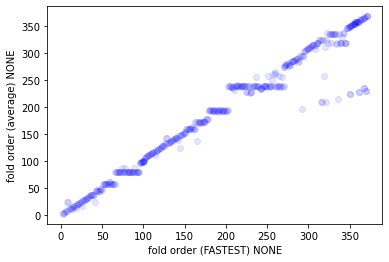

In [134]:
scatter(batm.folds_folditer, x2foAveNONE, 'fold order (FASTEST) NONE', 'fold order (average) NONE')

In [200]:
# try using bokeh

from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool

# Create a new plot
output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="fold order (FASTEST) vs. fold order (average)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(batm.folds_folditer, x2foAveNONE)
source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'fold order (FASTEST)'
p.yaxis.axis_label = 'fold order (average)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [145]:
# pick a several not-fastest runs
batm1 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-36_no_look_ahead_rules_ignore_versions_3141.pkl.gz')
batm2 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-54_no_look_ahead_rules_ignore_versions_3142.pkl.gz')
batm3 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-33-00_no_look_ahead_rules_ignore_versions_3143.pkl.gz')

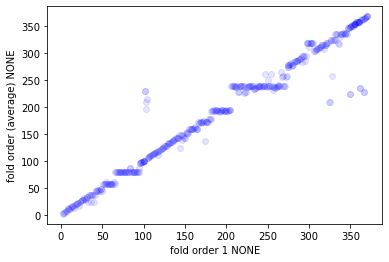

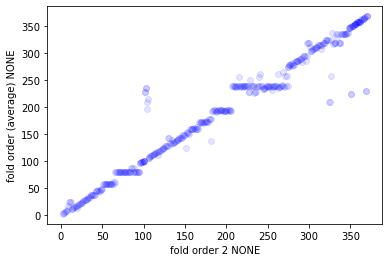

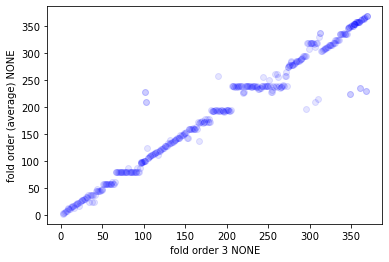

In [212]:
scatter(batm1.folds_folditer, x2foAveNONE, 'fold order 1 NONE', 'fold order (average) NONE')
scatter(batm2.folds_folditer, x2foAveNONE, 'fold order 2 NONE', 'fold order (average) NONE')
scatter(batm3.folds_folditer, x2foAveNONE, 'fold order 3 NONE', 'fold order (average) NONE')

In [147]:
x2foMeanStdNONE = csv2dict('../data/assets/xgroup2/xgroup2foMeanStdNONE.csv')

In [187]:
x2foMeanStdNONE.keys()

dict_keys(['2002', '1', '2487', '2006', '2003', '246', '7542', '62', '7525', '218', '2007', '304', '12', '11', '109', '10', '210', '7515', '279', '7577', '3016', '281', '7528', '331', '2011', '301', '7572', '206', '325', '282', '7527', '805', '7529', '180', '3691', '4126', '7512', '7518', '7560', '7579', '4002', '297', '286', '2004', '7580', '70', '205', '7554', '315', '2', '5104', '7567', '247', '307', '7561', '212', '7517', '5', '7510', '7571', '7574', '208', '7516', '387', '7573', '7552', '2493', '64', '302', '2485', '2498', '4081', '611', '328', '4021', '298', '2005', '149', '283', '810', '632', '2484', '3847', '103', '708', '185', '3651', '7520', '7543', '211', '164', '285', '7523', '7541', '4020', '4045', '355', '4178', '108', '4018', '7587', '7507', '7546', '812', '101', '223', '4019', '144', '3374', '278', '604', '7588', '4044', '7586', '4017', '3339', '702', '590', '2010', '7602', '7601', '4952', '602', '4953', '7524', '236', '221', '131', '129', '159', '7531', '213', '2486', 

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_66279/3478866884.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.xticks([])


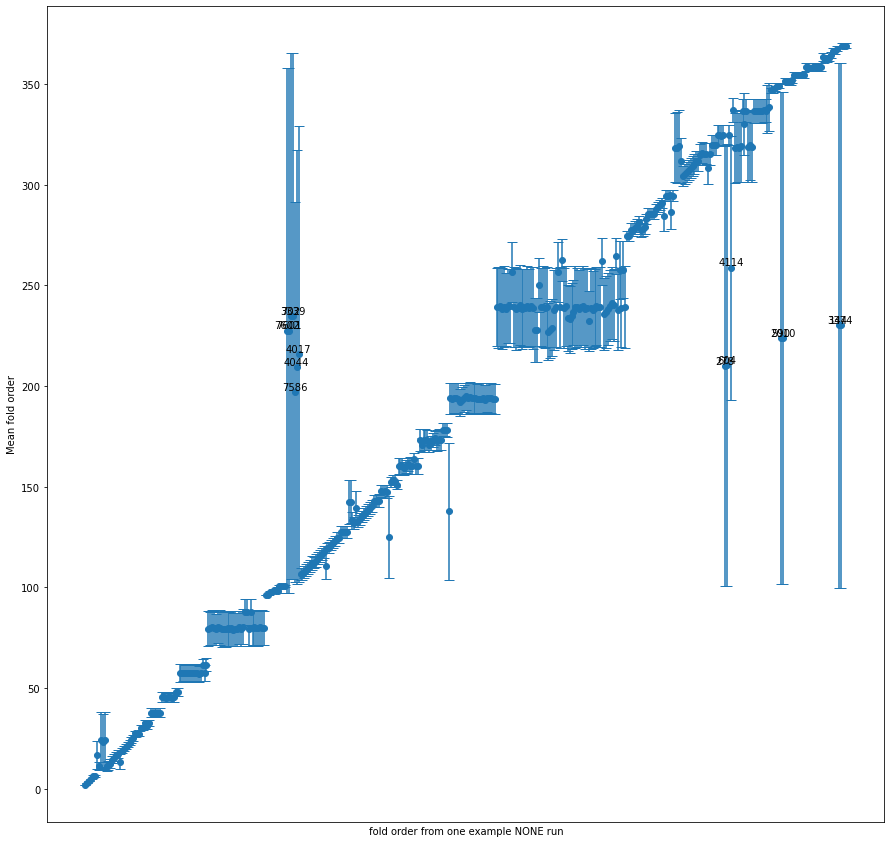

In [193]:
x_axis = list(batm2.folds_folditer.keys())[2:]
means = [x2foMeanStdNONE[key][0] for key in x_axis]
stds = [x2foMeanStdNONE[key][1] for key in x_axis]

plt.figure(figsize=(15, 15))
plt.errorbar(x_axis, means, yerr=stds, fmt='o', capsize=5)

# Add annotations
for key in ['7586', '278', '604', '4114', '4044', '4017', '590', '2010', '7601', '7602', '702', '3339', '3374', '144']:
    plt.text(key, x2foMeanStdNONE[key][0], str(key), ha='center', va='bottom', color='black')
#     plt.scatter(value, position-5, color='gray')


plt.xlabel('fold order from one example NONE run')
plt.ylabel('Mean fold order')
plt.xticks([])
plt.show()

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_66279/4154742252.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.xticks([])


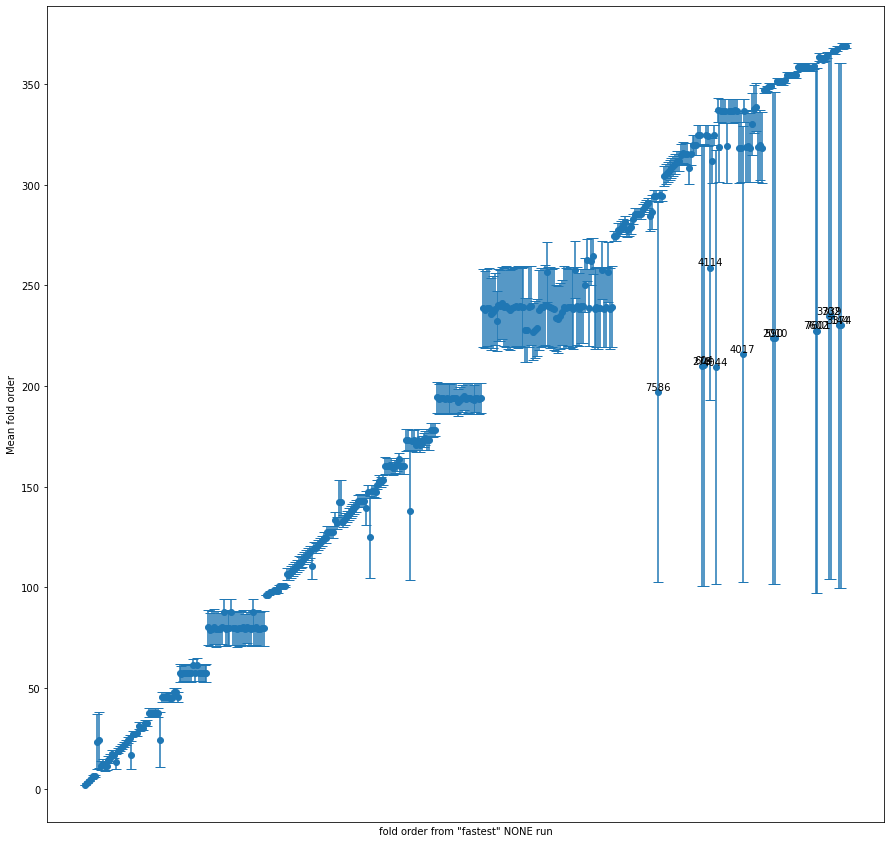

In [197]:
x_axis = list(batm.folds_folditer.keys())[2:]
means = [x2foMeanStdNONE[key][0] for key in x_axis]
stds = [x2foMeanStdNONE[key][1] for key in x_axis]

plt.figure(figsize=(15, 15))
plt.errorbar(x_axis, means, yerr=stds, fmt='o', capsize=5)

# Add annotations
for key in ['7586', '278', '604', '4114', '4044', '4017', '590', '2010', '7601', '7602', '702', '3339', '3374', '144']:
    plt.text(key, x2foMeanStdNONE[key][0], str(key), ha='center', va='bottom', color='black')
#     plt.scatter(value, position-5, color='gray')


plt.xlabel('fold order from "fastest" NONE run')
plt.ylabel('Mean fold order')
plt.xticks([])
plt.show()

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_66279/239889372.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.xticks([])


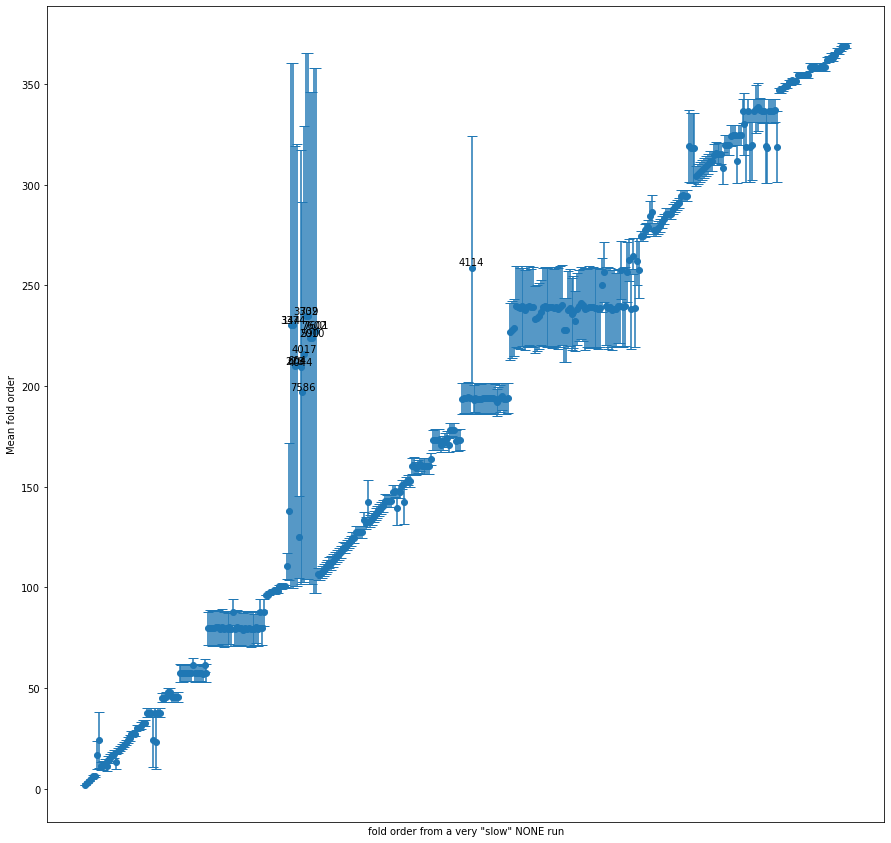

In [196]:
x_axis = list(x2foMeanStdNONE.keys())
means = [x2foMeanStdNONE[key][0] for key in x_axis]
stds = [x2foMeanStdNONE[key][1] for key in x_axis]

plt.figure(figsize=(15, 15))
plt.errorbar(x_axis, means, yerr=stds, fmt='o', capsize=5)

# Add annotations
for key in ['7586', '278', '604', '4114', '4044', '4017', '590', '2010', '7601', '7602', '702', '3339', '3374', '144']:
    plt.text(key, x2foMeanStdNONE[key][0], str(key), ha='center', va='bottom', color='black')
#     plt.scatter(value, position-5, color='gray')


plt.xlabel('fold order from a very "slow" NONE run')
plt.ylabel('Mean fold order')
plt.xticks([])
plt.show()

In [198]:
slow = pd.read_pickle('../2023-09-21_11-42-33_random_fold_ordering_40132-fixed-rn-seeds.pkl')

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_66279/815193479.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.xticks([])


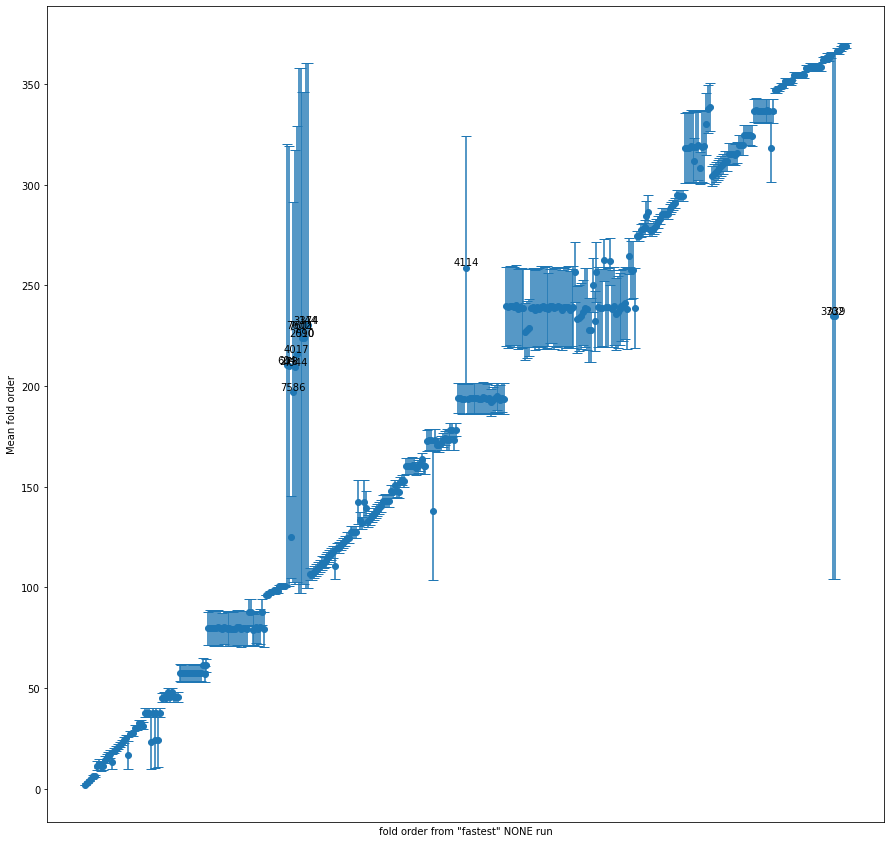

In [199]:
x_axis = list(slow.folds_folditer.keys())[2:]
means = [x2foMeanStdNONE[key][0] for key in x_axis]
stds = [x2foMeanStdNONE[key][1] for key in x_axis]

plt.figure(figsize=(15, 15))
plt.errorbar(x_axis, means, yerr=stds, fmt='o', capsize=5)

# Add annotations
for key in ['7586', '278', '604', '4114', '4044', '4017', '590', '2010', '7601', '7602', '702', '3339', '3374', '144']:
    plt.text(key, x2foMeanStdNONE[key][0], str(key), ha='center', va='bottom', color='black')
#     plt.scatter(value, position-5, color='gray')


plt.xlabel('fold order from "fastest" NONE run')
plt.ylabel('Mean fold order')
plt.xticks([])
plt.show()

In [ ]:
# in fastest runs, the 'garbage folds' (from zone of redundance) all come late

In [ ]:
for x in ['7586', '278', '604', '4114', '4044', '4017', '590', '2010', '7601', '7602', '702', '3339', '3374', '144']:
    